# Atividade ATV1 – N2 – Mapa de Calor São Paulo 2025-2026
Análise de Queimadas no Estado de São Paulo.

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np

# Configurações de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregando os dados
df = pd.read_csv('bdqueimadas_2025-04-29_2026-04-30.csv')

### 1. Verifique a quantidade de colunas com valores vazias do arquivo

In [137]:
colunas_vazias = df.isnull().sum()
print("Quantidade de valores vazios por coluna:")
print(colunas_vazias[colunas_vazias > 0])
print(f"\nTotal de colunas com pelo menos um valor vazio: {(colunas_vazias > 0).sum()}")

Quantidade de valores vazios por coluna:
Series([], dtype: int64)

Total de colunas com pelo menos um valor vazio: 0


### 2. Mostre a Estatística do FRP

In [138]:
# Estatísticas do FRP formatadas
frp = pd.to_numeric(df['FRP'], errors='coerce')
total_registros = len(df)
count = int(frp.count())
missing = int(frp.isna().sum())
missing_pct = (missing / total_registros) * 100 if total_registros > 0 else 0
mean = frp.mean()
std = frp.std()
min_v = frp.min()
q1 = frp.quantile(0.25)
median = frp.median()
q3 = frp.quantile(0.75)
max_v = frp.max()
# Outliers via IQR
IQR = q3 - q1
lim_inf = q1 - 1.5 * IQR
lim_sup = q3 + 1.5 * IQR
outliers = frp[(frp < lim_inf) | (frp > lim_sup)]
outlier_count = int(outliers.count())
outlier_pct = (outlier_count / count) * 100 if count > 0 else 0
# Coeficiente de variação (em %)
cv_pct = (std / mean) * 100 if mean not in (0, None) and pd.notna(mean) else float('nan')

print('Estatísticas do FRP (Fire Radiative Power):')
print(f'Count: {count}')
print(f'Mean: {mean:.2f}')
print(f'Std: {std:.2f}')
print(f'Min: {min_v:.2f}')
print(f'25% (Q1): {q1:.2f}')
print(f'50% (Median): {median:.2f}')
print(f'75% (Q3): {q3:.2f}')
print(f'Max: {max_v:.2f}')
print(f'Missing: {missing} ({missing_pct:.2f}% )')
print(f'Outliers (IQR): {outlier_count} ({outlier_pct:.2f}% )')
if pd.notna(cv_pct):
    print(f'Coef. de Variação (CV): {cv_pct:.2f}%')

Estatísticas do FRP (Fire Radiative Power):
Count: 2351
Mean: 55.96
Std: 114.20
Min: 3.10
25% (Q1): 10.25
50% (Median): 20.20
75% (Q3): 49.60
Max: 1543.90
Missing: 0 (0.00% )
Outliers (IQR): 271 (11.53% )
Coef. de Variação (CV): 204.07%


### 3. Com base na estatística indique quantos focos de incêndio encontram-se fora da curva

In [139]:
# Utilizando o método do Intervalo Interquartil (IQR) para identificar outliers (fora da curva)
Q1 = df['FRP'].quantile(0.25)
Q3 = df['FRP'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['FRP'] < limite_inferior) | (df['FRP'] > limite_superior)]
quantidade_outliers = outliers.shape[0]

print(f"Limite Inferior: {limite_inferior:.2f}")
print(f"Limite Superior: {limite_superior:.2f}")
print(f"Quantidade de focos de incêndio fora da curva (outliers): {quantidade_outliers}")

Limite Inferior: -48.78
Limite Superior: 108.62
Quantidade de focos de incêndio fora da curva (outliers): 271


### 4. Gere um gráfico de barras que demonstre o padrão dos focos de queimadas

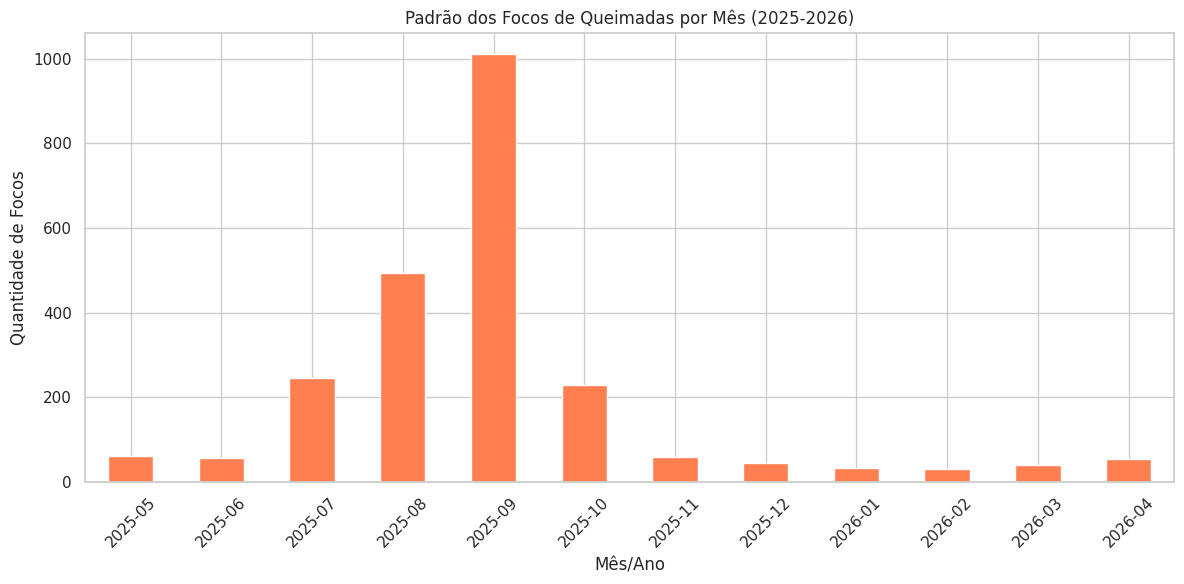

In [140]:
# Analisando o padrão de focos de queimadas por mês
df['DataHora'] = pd.to_datetime(df['DataHora'])
df['MesAno'] = df['DataHora'].dt.to_period('M')

focos_por_mes = df['MesAno'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
focos_por_mes.plot(kind='bar', color='coral')
plt.title('Padrão dos Focos de Queimadas por Mês (2025-2026)')
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Focos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Gere um gráfico que demonstre as TOP 5 cidades com maior índice de queimadas no estado de São Paulo no ultimo ano.

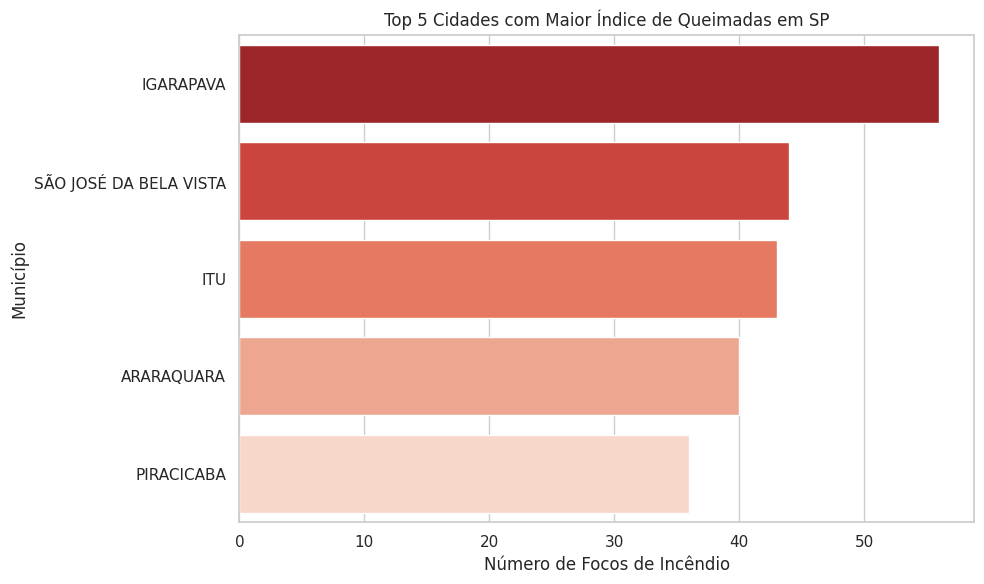

In [141]:
top_5_cidades = df['Municipio'].value_counts().head(5)
top_5_df = top_5_cidades.reset_index()
top_5_df.columns = ['Municipio', 'Focos']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_df, x='Focos', y='Municipio', hue='Municipio', palette='Reds_r', legend=False)
plt.title('Top 5 Cidades com Maior Índice de Queimadas em SP')
plt.xlabel('Número de Focos de Incêndio')
plt.ylabel('Município')
plt.tight_layout()
plt.show()

### 6. Gere um gráfico de dispersão utilizando a imagem em anexo disponível para demonstrar ilustradamente os pontos de focos de queimadas no estado de São Paulo no ultimo ano.

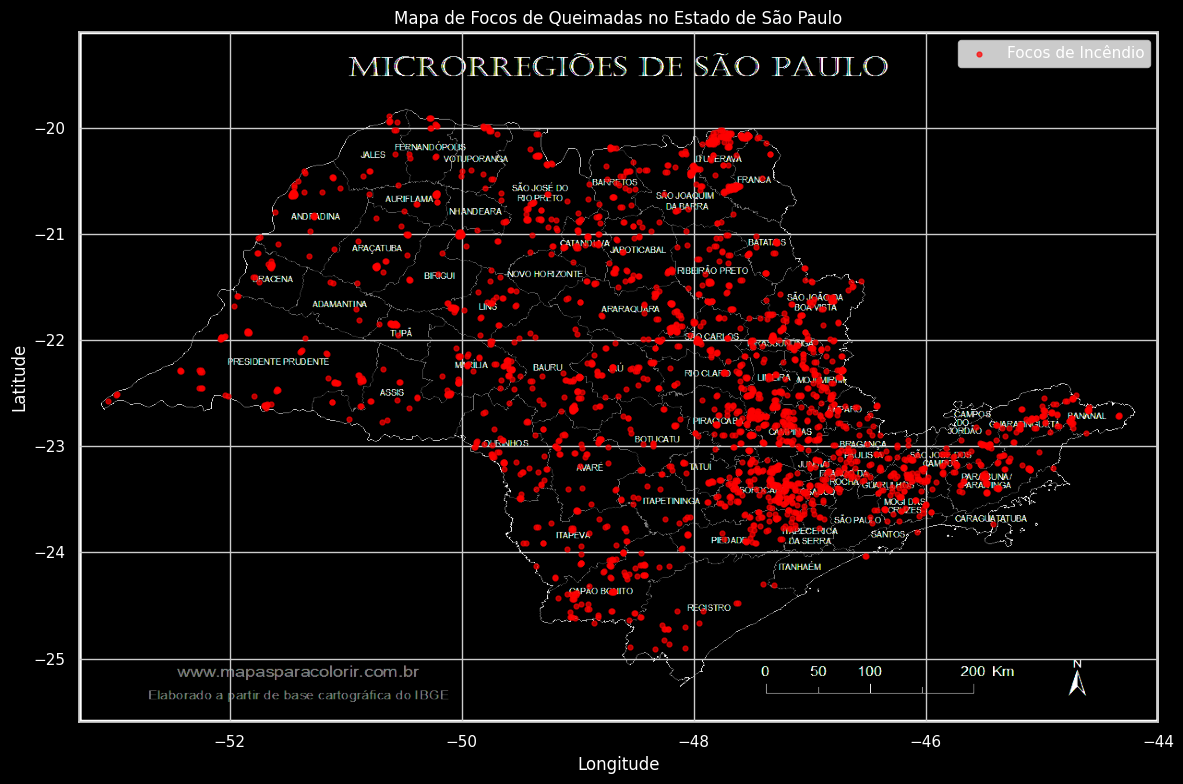

In [142]:
from PIL import Image

# Carregando a imagem do mapa de São Paulo
img_mapa = Image.open('estado-sao-paulo-microrregioes.png')

# Preparar dados: remover NA e garantir floats
df_coords = df.dropna(subset=['Longitude','Latitude']).copy()
df_coords['Longitude'] = pd.to_numeric(df_coords['Longitude'], errors='coerce')
df_coords['Latitude'] = pd.to_numeric(df_coords['Latitude'], errors='coerce')
df_coords = df_coords.dropna(subset=['Longitude','Latitude'])

# Detectar se as colunas foram trocadas (heurística simples)
# Para o Brasil, longitudes esperadas ~ -74 a -34 e latitudes ~ -34 a 6
if (df_coords['Longitude'].abs().max() < 15) and (df_coords['Latitude'].abs().max() > 15):
    df_coords[['Longitude','Latitude']] = df_coords[['Latitude','Longitude']]

# Limites geográficos aproximados do estado de SP (lon_min, lon_max, lat_min, lat_max)
lon_min, lon_max = -53.3, -44.0
lat_min, lat_max = -25.6, -19.1

extent = [lon_min, lon_max, lat_min, lat_max]

# Manter somente pontos dentro do mapa para evitar dispersão fora da imagem
mask_sp = (
    df_coords['Longitude'].between(lon_min, lon_max)
    & df_coords['Latitude'].between(lat_min, lat_max)
)
df_plot = df_coords.loc[mask_sp].copy()

# Criando o gráfico de dispersão sobre a imagem com fundo preto
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Exibir a imagem com a extensão geográfica e origem ajustada caso necessário
# origin='upper' costuma ser útil quando a imagem parece invertida
ax.imshow(img_mapa, extent=extent, aspect='auto', origin='upper')

# Plotando os pontos de dispersão (Longitude vs Latitude)
ax.scatter(df_plot['Longitude'], df_plot['Latitude'], alpha=0.7, c='red', s=12, label='Focos de Incêndio')

# Trava os eixos na área do mapa
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Ajustes visuais para fundo preto
ax.set_title('Mapa de Focos de Queimadas no Estado de São Paulo', color='white')
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.tick_params(colors='white')
legend = ax.legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_color('white')

plt.tight_layout()
plt.show()